# Shendure MWU power — all cell types

Assesses MWU power (TPR) as a function of CRE_oi strength relative to `minP`, for every cell type in the Shendure dataset.

For each cell type:
1. Draw `n_cres` synthetic CREs from uniform(min, max), with one fixed at `minP` as the reference
2. Simulate `cells_per_cell_type` cells (matching the real count for that cell type) across `n_sims` replicates, repeated 100 times
3. Run MWU for all CREs vs. reference
4. Aggregate and plot per-cell-type power curves

Each cell type is simulated independently with its own empirical `(n_cres, cell_count)` pair.
`one_library_replicate` now accepts a `cell_type` parameter so real names flow through cleanly.

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

2026-03-18 20:31:51.346107: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 20:31:51.402692: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-18 20:31:51.402711: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
data_root = Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sim_date = "2026-03-18"

In [3]:

local = False
if local:
    cluster = LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster = SLURMCluster(
        cores=3,
        memory="16G",
        processes=3,          # 1 process per core: 3 workers per job, fixes GIL bottleneck
        worker_extra_args=["--nthreads", "2"],  # deadlock headroom
        job_extra_directives=[
            "-p priority",
            "-A prio_skr2",
            "--job-name=simclust_worker",
            "--time=6:00:00",
            "--output=worker_%j.out"
        ]
    )
    cluster.scale(jobs=10)  # 10 jobs x 3 workers = 30 workers total
    client = Client(
        cluster,
        timeout=f"{5*60}s",
        heartbeat_interval="20s"
    )
print(client.dashboard_link, flush=True)


http://10.18.22.74:8787/status


In [4]:

# Load primordial to get per-cell-type n_cres from post-ortho_filter training data.
# For Shendure (integrating vector + bottleneck), detected n_cres per cell type
# reflects CREs that genuinely survived into that lineage.
primordial = scm.ortho.load(client, data_root / "shendure", "shendure_ortho_20260306")
dat = primordial.training_data.data.compute()

cell_types = sorted(dat["cell_type"].unique().tolist())
n_cres_per_ct = {
    ct: len(dat[dat["cell_type"] == ct]["cre_id"].unique())
    for ct in cell_types
}
del primordial

print("Cell types and parameters:")
for ct in cell_types:
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "N/A")
    print(f"  {ct}: n_cres={n_cres_per_ct[ct]}, cells={cells}")


Cell types and parameters:
  Cardiomyocytes: n_cres=79, cells=680
  EpiblastPrimitiveStreak: n_cres=185, cells=3445
  ExEndodermParietal: n_cres=178, cells=4644
  ExEndodermVisceral: n_cres=148, cells=3238
  Haematoendothelial: n_cres=91, cells=1079
  Mesoderm: n_cres=177, cells=7427
  NeuroectodermBrain: n_cres=173, cells=7750
  NeuroectodermRostral: n_cres=85, cells=1757
  SurfaceEctoderm: n_cres=139, cells=5168
  reference: n_cres=207, cells=8201


In [5]:
max_activity = 0.05
min_activity = scm.SHENDURE_BOUNDS.min_mpra_umi
minP = scm.SHENDURE_BOUNDS.reference_activity
n_library_reps = 100
n_sims = 5
print(f"minP={minP:.6f}, min={min_activity:.6f}, max={max_activity}")

minP=0.019311, min=0.003474, max=0.05


In [6]:
all_sims = {}  # {cell_type: [sim, ...]}

for cell_type in cell_types:
    print(f"\n=== {cell_type} ===", flush=True)

    bound_ct = scm.SHENDURE_BOUNDS.copy()
    bound_ct.cells_per_cell_type = scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[[cell_type]]

    sims_ct = []
    for i in range(n_library_reps):
        _, sim = scm.one_library_replicate(
            root=data_root / f"{sim_date}_shendure_pow" / cell_type,
            n_sims=n_sims,
            client=client,
            flatten_overtransfection=False,
            bound=bound_ct,
            n_cres=n_cres_per_ct[cell_type],
            min=min_activity,
            max=max_activity,
            minP=minP,
            cell_type=cell_type,
        )
        sims_ct.append(sim)

    all_sims[cell_type] = sims_ct
    print(f"  {n_library_reps} replicates done", flush=True)


=== Cardiomyocytes ===


scMPRAforge: INFO: No 'state.parquet' found for 'sim_5af9612b'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_12691611'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_b9b7c8e6'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_6be8601a'. Initalizing new object.


...

scMPRAforge: INFO: No 'state.parquet' found for 'sim_c3e8eff8'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_a7b70d42'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_1a3cb56e'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_208dae86'. Initalizing new object.


  100 replicates done


In [7]:
for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("Saved.", flush=True)

Saved.


In [8]:
# Build a hypothesis set per cell type from its first simulation's data.
for cell_type, sims in all_sims.items():
    print(f"MWU: {cell_type}", flush=True)
    example = scm.scMPRA_data.from_parquet(sims[0].scmpradatp / "0.scmpra")
    hs = scm.make_all_by_celltype_hypotheses(counts=example, reference_cre="reference")
    for sim in sims:
        sim.add_hypothesis_set("hs_all_ct", hs)
        sim.mwu("hs_all_ct")

for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("MWU done and saved.", flush=True)

MWU: Cardiomyocytes


MWU: EpiblastPrimitiveStreak


MWU: ExEndodermParietal


MWU: ExEndodermVisceral


MWU: Haematoendothelial


...

MWU: NeuroectodermBrain


MWU: NeuroectodermRostral


MWU: SurfaceEctoderm


MWU: reference


MWU done and saved.


In [9]:
all_mergy = {
    ct: scm.sum_pow(sims, hypothesis_set_name="hs_all_ct", test_type="mwu")
    for ct, sims in all_sims.items()
}

Saved: output/power_mwu_all_cell_types.svg


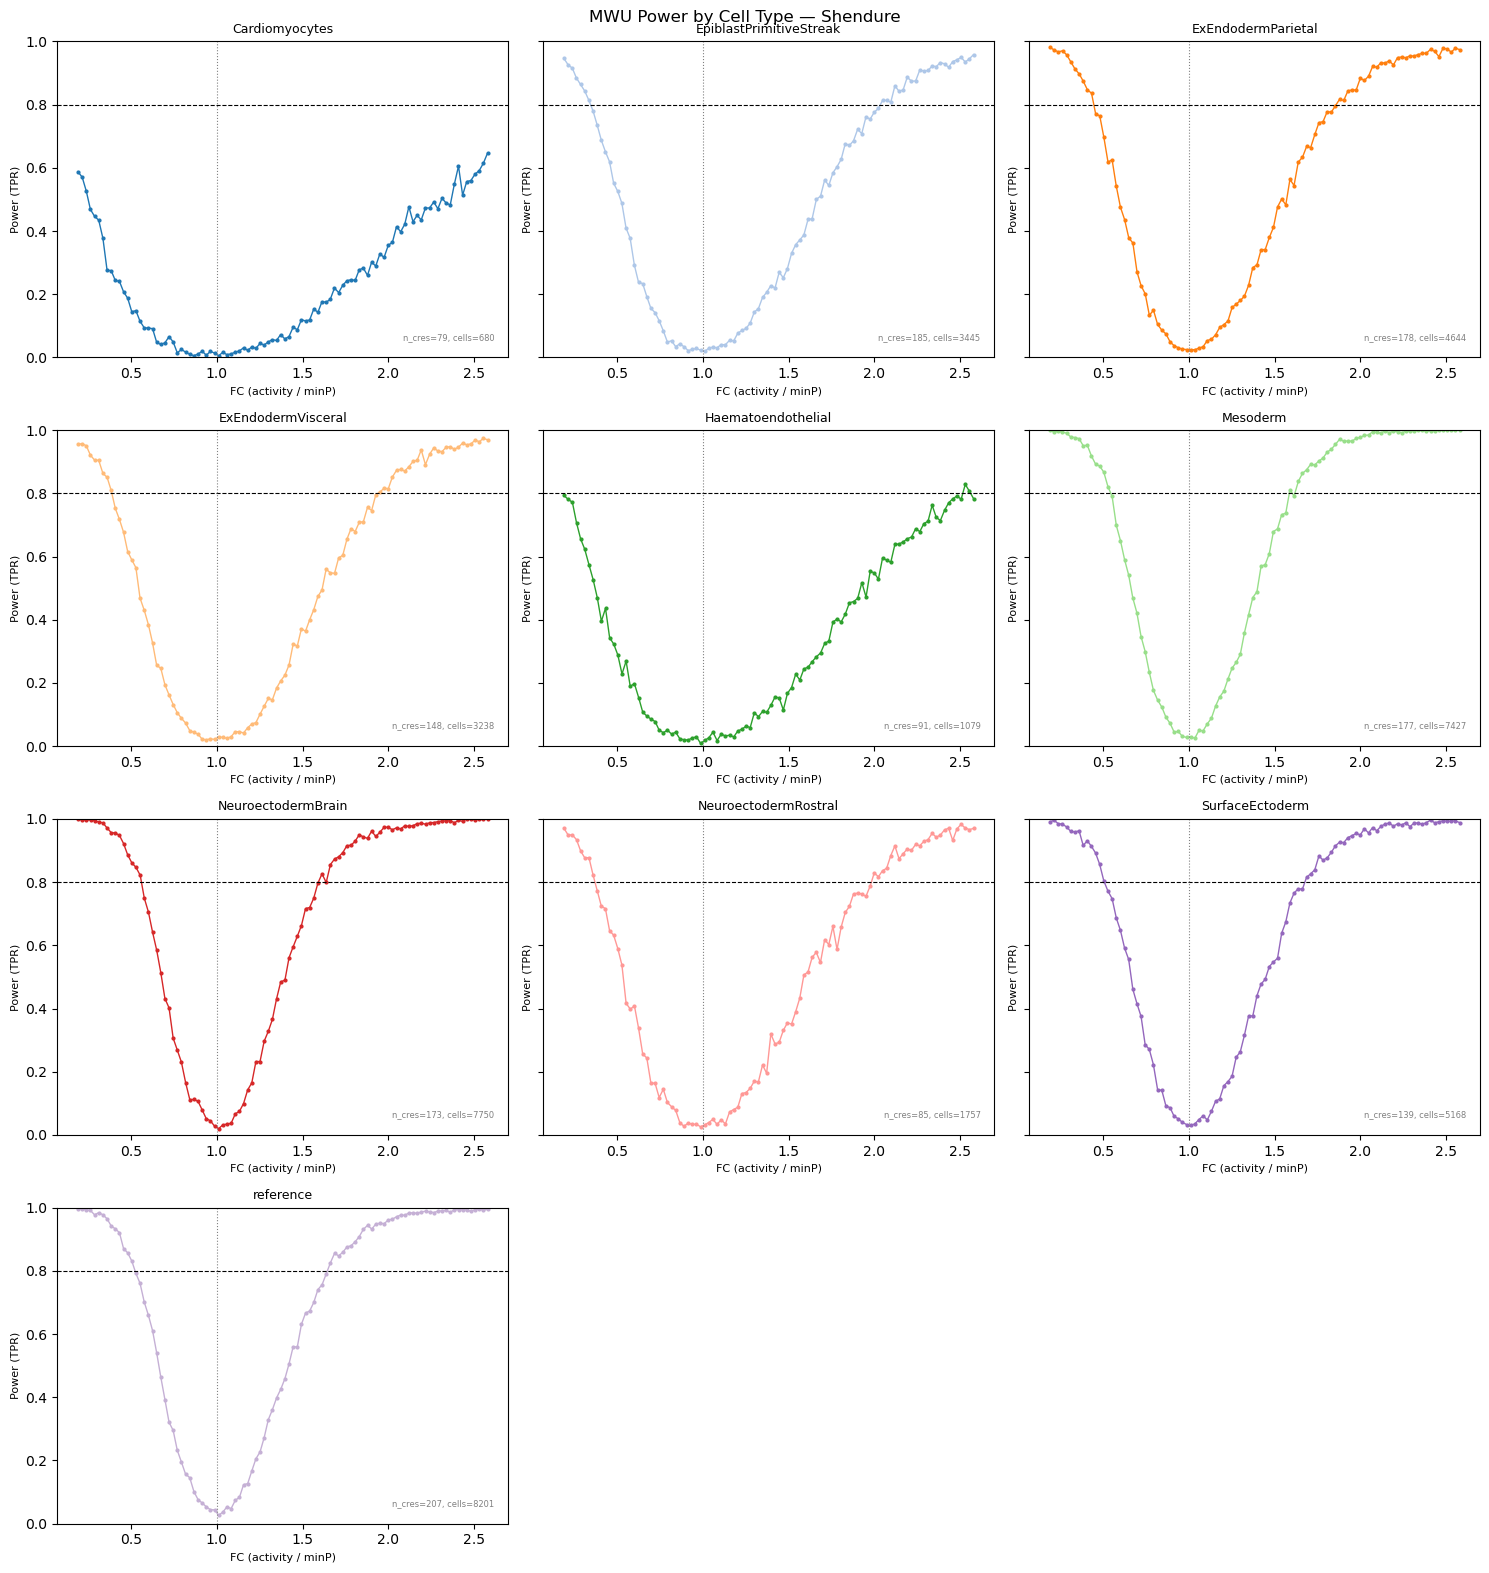

In [10]:
def _pow_curve_data(mergy, n_bins=100):
    df = mergy.copy()
    df["fc"] = pd.cut(df["fc"], bins=n_bins)
    binned = (
        df.groupby("fc", observed=True)["reject_null"]
        .mean()
        .reset_index(name="reject_frac")
    )
    binned["bin_center"] = binned["fc"].apply(lambda x: x.mid)
    return binned

ncols = 3
nrows = math.ceil(len(cell_types) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
palette = sns.color_palette("tab20", n_colors=len(cell_types))

for i, cell_type in enumerate(cell_types):
    binned = _pow_curve_data(all_mergy[cell_type])
    ax = axes[i]
    ax.plot(binned["bin_center"], binned["reject_frac"],
            color=palette[i], marker="o", markersize=2, linewidth=1)
    ax.axhline(0.8, color="black", linestyle="--", lw=0.8)
    ax.axvline(1.0, color="grey", linestyle=":", lw=0.8)
    ax.set_title(cell_type, fontsize=9)
    ax.set_xlabel("FC (activity / minP)", fontsize=8)
    ax.set_ylabel("Power (TPR)", fontsize=8)
    ax.set_ylim(0, 1)
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(cell_type, "?")
    ax.text(0.97, 0.05,
            f"n_cres={n_cres_per_ct[cell_type]}, cells={cells}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="grey")

for j in range(len(cell_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MWU Power by Cell Type — Shendure", fontsize=12)
plt.tight_layout()
svg_path = output_dir / "power_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

In [11]:
client.close()
cluster.close()

Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/session.py", line 106, in _needs_document_lock_wrapper
    await p
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 284, in send_message
    await message.send(self)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/protocol/message.py", line 316, in send
    await conn.write_message(self.metadata_json, locked=False)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 300, in write_message
    await super().wri

Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
asyncio.exceptions.CancelledError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
asyncio.exceptions.Cancell

Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
asyncio.exceptions.CancelledError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
asyncio.exceptions.Cancell